# Wake post-processing (wake1)

Binary Tecplot (.plt) -> Zarr -> slices, line probes, and plots.

Data: inputs/flood-log-7/


## Setup - paths and imports


In [10]:
from pathlib import Path

ROOT = Path('.').resolve()
DATA = ROOT / 'inputs' / 'flood-log-7'
PLT = DATA / 'Result015000-avg.plt'
ZARR = DATA / 'Result015000-avg.zarr'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

import sys
sys.path.insert(0, str(ROOT / 'tools'))

# Pick up edits to tools/*.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from tecplot_binary import TecplotBinaryDataset
from wake_store import WakeStore, node_to_cell_2d

print('ROOT:', ROOT)
print('PLT exists:', PLT.is_file())
print('Zarr exists:', ZARR.is_dir())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ROOT: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis
PLT exists: True
Zarr exists: True


## 1 - Install dependencies (run once)


In [11]:
#!python -m pip install -r requirements.txt

## 2 - Ingest binary to Zarr (run once per case)


In [12]:
#import subprocess
#subprocess.run(
#    ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT), '-o', str(ZARR), '--overwrite'],
#    check=True,
#)

Optional: subset ingest (faster)


In [13]:
# subprocess.run(
#     ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT), '-o', str(ZARR),
#      '--vars', 'X', 'Y', 'Z', 'U', 'V', 'W', 'K', '--overwrite'],
#     check=True,
# )

## 3 - Inspect Tecplot binary metadata


In [14]:
ds = TecplotBinaryDataset(PLT, read_data=False)
print(ds.summary())


file: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.plt
title: Averaging
zone: Block 1
ijk: I=1325, J=73, K=1325 (128,160,625 nodes)
variables (14):
  X     node  shape=(1325, 73, 1325)
  Y     node  shape=(1325, 73, 1325)
  Z     node  shape=(1325, 73, 1325)
  U     cell  shape=(1324, 72, 1324)
  V     cell  shape=(1324, 72, 1324)
  W     cell  shape=(1324, 72, 1324)
  uu    cell  shape=(1324, 72, 1324)
  vv    cell  shape=(1324, 72, 1324)
  ww    cell  shape=(1324, 72, 1324)
  uv    cell  shape=(1324, 72, 1324)
  vw    cell  shape=(1324, 72, 1324)
  uw    cell  shape=(1324, 72, 1324)
  K     cell  shape=(1324, 72, 1324)
  Nv    cell  shape=(1324, 72, 1324)


## 4 - Inspect Zarr store


In [15]:
store = WakeStore.open(ZARR)
print(store.summary())

store: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.zarr
title: Averaging
source: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.plt
ijk: I=1325, J=73, K=1325
variables:
  X     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  Y     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  Z     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  U     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  V     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  W     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uu    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  vv    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  ww    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uv    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  vw    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uw    cell  shape=(1324, 72, 1324)  ch

In [16]:
import subprocess
subprocess.run(['python', 'scripts/wake_postprocess.py', str(ZARR), 'info'], check=True)

CompletedProcess(args=['python', 'scripts/wake_postprocess.py', 'C:\\Users\\hseyyedzadeh\\Box\\Projects\\Verdant\\data-analysis\\cfd-wake-analysis\\inputs\\flood-log-7\\Result015000-avg.zarr', 'info'], returncode=0)

## 5 - Map physical Y to grid index J (for Y = 0.65)


In [17]:
TARGET_Y = 0.65

Y = store.read('Y')
y_at_j = Y.mean(axis=(0, 2))
j_idx = int(np.argmin(np.abs(y_at_j - TARGET_Y)))

print(f'Target Y = {TARGET_Y}')
print(f'J index = {j_idx},  Y on plane ~ {y_at_j[j_idx]:.4f}')
print(f'Y range on grid: [{y_at_j.min():.4f}, {y_at_j.max():.4f}]')

Target Y = 0.65
J index = 63,  Y on plane ~ 0.6613
Y range on grid: [-0.2801, 0.9813]


## 6 - Contour of W on vertical plane (XZ at Y ~ 0.65)


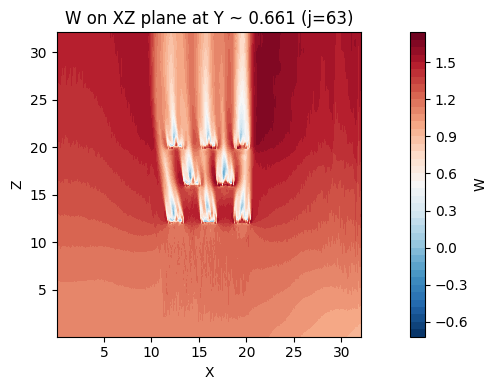

In [18]:
sl = store.slice_plane('XZ', j_idx, variables=['X', 'Z', 'W'])
X, Z, W = sl.arrays['X'], sl.arrays['Z'], sl.arrays['W']

# Average node coords in I and K so Xc, Zc match cell-centered W shape
Xc = node_to_cell_2d(X)
Zc = node_to_cell_2d(Z)
assert Xc.shape == W.shape == Zc.shape, (Xc.shape, W.shape, Zc.shape)

fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.contourf(Xc, Zc, W, levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='W')
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_title(f'W on XZ plane at Y ~ {y_at_j[j_idx]:.3f} (j={j_idx})')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()